In [30]:
import tensorflow as tf
from tensorflow.keras import layers, Model
import numpy as np

This cell imports the TensorFlow and Keras libraries, which are used for building neural networks. It specifically imports the `layers` and `Model` classes, and also imports NumPy.

In [31]:
(x_train, _), (x_test, _) = tf.keras.datasets.mnist.load_data()

x_train = x_train.astype("float32") / 255.
x_test = x_test.astype("float32") / 255.

x_train = np.reshape(x_train, (-1, 28, 28, 1))
x_test = np.reshape(x_test, (-1, 28, 28, 1))

This cell loads the MNIST dataset, which consists of handwritten digit images. It scales the data to a range of 0 to 1 and reshapes it to the correct format for the VAE model.

In [32]:
latent_dim = 2  # size of latent space

encoder_inputs = layers.Input(shape=(28, 28, 1))
x = layers.Flatten()(encoder_inputs)
x = layers.Dense(128, activation="relu")(x)

z_mean = layers.Dense(latent_dim)(x)
z_log_var = layers.Dense(latent_dim)(x)

This cell defines the encoder part of the VAE. It transforms the input image into a smaller 'latent space'. `latent_dim` is the size of this latent space. `z_mean` and `z_log_var` represent the mean and variance of the latent space.

In [33]:
def sampling(args):
    z_mean, z_log_var = args
    epsilon = tf.random.normal(shape=(tf.shape(z_mean)[0], latent_dim))
    return z_mean + tf.exp(0.5 * z_log_var) * epsilon

z = layers.Lambda(sampling)([z_mean, z_log_var])

This cell defines the 'sampling' function, which uses the reparameterization trick to generate a latent vector `z` from the `z_mean` and `z_log_var` learned by the encoder. This ensures that the model's training is proper.

In [34]:
decoder_inputs = layers.Input(shape=(latent_dim,))
x = layers.Dense(128, activation="relu")(decoder_inputs)
x = layers.Dense(28 * 28, activation="sigmoid")(x)
decoder_outputs = layers.Reshape((28, 28, 1))(x)

decoder = Model(decoder_inputs, decoder_outputs, name="decoder")

This cell defines the decoder part of the VAE. The decoder takes a `z` vector from the latent space and attempts to reconstruct an image from it.

In [35]:
encoder = Model(encoder_inputs, [z_mean, z_log_var, z], name="encoder")

outputs = decoder(z)
vae = Model(encoder_inputs, outputs, name="vae")

This cell combines the encoder and decoder to form the complete VAE model. The encoder takes input and outputs `z_mean`, `z_log_var`, and `z`, and then `z` is passed to the decoder to reconstruct the image.

In [36]:
import tensorflow as tf
from tensorflow.keras import Model

class VAE(Model):
    def __init__(self, encoder, decoder):
        super(VAE, self).__init__()
        self.encoder = encoder
        self.decoder = decoder

    def train_step(self, data):
        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)

            # Reconstruction loss
            recon_loss = tf.reduce_mean(
                tf.keras.losses.binary_crossentropy(data, reconstruction)
            ) * 28 * 28

            # KL loss
            kl_loss = -0.5 * tf.reduce_mean(
                1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var)
            )

            total_loss = recon_loss + kl_loss

        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

        return {
            "loss": total_loss,
            "reconstruction_loss": recon_loss,
            "kl_loss": kl_loss,
        }

### VAE Model Class
This custom `VAE` class inherits from `tf.keras.Model` and defines a custom `train_step` method. This method is crucial for implementing the VAE's unique loss function, which consists of two parts:

1.  **Reconstruction Loss**: Measures how well the decoder reconstructs the input image from the latent representation. For images, binary cross-entropy is often used.
2.  **KL Divergence Loss**: This term regularizes the latent space, ensuring that the learned latent distribution (`z_mean` and `z_log_var`) is close to a standard normal distribution. This encourages a well-structured and continuous latent space, allowing for meaningful interpolations and sampling.

The `train_step` calculates both these losses, sums them up to get the `total_loss`, and then applies gradient descent to update the model's weights.

In [37]:
vae = VAE(encoder, decoder)
vae.compile(optimizer="adam")

This cell creates an instance of the VAE model and compiles it with the `adam` optimizer.

In [38]:
vae.fit(x_train, epochs=20, batch_size=128)

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - kl_loss: 3.3240 - loss: 190.3654 - reconstruction_loss: 187.0414
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - kl_loss: 3.5221 - loss: 166.7605 - reconstruction_loss: 163.2384
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - kl_loss: 3.6462 - loss: 149.9208 - reconstruction_loss: 146.2745
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - kl_loss: 3.5244 - loss: 159.8540 - reconstruction_loss: 156.3295
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - kl_loss: 3.0171 - loss: 167.2334 - reconstruction_loss: 164.2163
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - kl_loss: 3.4060 - loss: 166.7889 - reconstruction_loss: 163.3829
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - kl_loss: 3.1960 - loss: 164.7486 - reconstruction_loss: 161.5526
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - kl_loss: 3.4577 - loss: 160.3105 - reconstruction_loss: 156.8528
Epoch 9/20
469/469 ━━━━━━━━━━━━━━━━━━━━

This cell trains the VAE model on the `x_train` data for 20 epochs. You can observe the training progress (loss values) in the output.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step


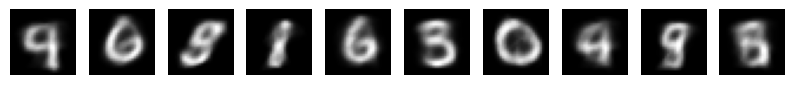

In [39]:
import matplotlib.pyplot as plt

# Sample from latent space
z_sample = np.random.normal(size=(10, latent_dim))
generated_images = decoder.predict(z_sample)

plt.figure(figsize=(10, 2))
for i in range(10):
    plt.subplot(1, 10, i + 1)
    plt.imshow(generated_images[i].reshape(28, 28), cmap="gray")
    plt.axis("off")
plt.show()

After training, this cell generates 10 new images by taking random samples from the latent space and plots them. This demonstrates how the VAE has learned the patterns of MNIST digits.